## Loading the data & data exploration

In [1]:
# Import necessary libraries
import pandas as pd
from sklearn.model_selection import train_test_split
import string
from nltk.corpus import stopwords
import nltk

In [2]:
# Load the CSV file into a DataFrame
df_localization = pd.read_csv('language_analysis/df_localization.csv')

# Display the first rows of the DataFrame
print(df_localization.head())

    productid     imageid  prdtypecode  bool_description  \
0  3804725264  1263597046           10                 0   
1   436067568  1008141237         2280                 0   
2   201115110   938777978           50                 1   
3    50418756   457047496         1280                 0   
4   278535884  1077757786         2705                 1   

                                         merged_text lang  \
0  Olivia: Personalisiertes Notizbuch / 150 Seite...   de   
1  Journal Des Arts Le N° 133 Du 28/09/2001 - L'a...   fr   
2  PILOT STYLE Touch Pen de marque Speedlink est ...   fr   
3  Peluche Donald - Europe - Disneyland 2000 Mari...   fr   
4  La Guerre Des Tuques - Luc a des idées de gran...   fr   

                                   deepL_translation  
0  Olivia : Carnet de notes personnalisé / 150 pa...  
1                                                NaN  
2                                                NaN  
3                                                NaN

## Preprocessing

In [3]:
# Download the stopwords list if not already downloaded
nltk.download('stopwords')

# Get the French stop words
french_stop_words = set(stopwords.words('french'))

# Function to preprocess text: lowercase, remove punctuation, and remove stop words
def preprocess_text(text):
    if pd.isna(text):  # Handle NaN values
        return ""
    text = text.lower()  # Convert to lowercase, because stopwords are case-sensitive.
    text = text.translate(str.maketrans('', '', string.punctuation))  # Remove punctuation
    text = ' '.join([word for word in text.split() if word not in french_stop_words])  # Remove stop words
    return text

# Create a new DataFrame with the "text" column
df_processed = df_localization.copy()
df_processed['text'] = df_processed.apply(
    lambda row: preprocess_text(row['deepL_translation']) if pd.notna(row['deepL_translation']) else preprocess_text(row['merged_text']),
    axis=1
)

# Retain only the "text" and "prdtypecode" columns
df_processed = df_processed[['text', 'prdtypecode']]

# Display the first rows of the new DataFrame
print(df_processed.head())

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/robertwilson/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


                                                text  prdtypecode
0  olivia carnet notes personnalisé 150 pages gri...           10
1  journal arts n° 133 28092001 lart marche salon...         2280
2  pilot style touch pen marque speedlink 1 style...           50
3  peluche donald europe disneyland 2000 marionne...         1280
4  guerre tuques luc a idées grandeur veut organi...         2705


## Check df for correct size

In [5]:
# Print the shape of the new DataFrame
print(df_processed.shape)

(84916, 2)


## Data Splits: Feature & Target Data, Train & Test Data

Unstratified Split

In [ ]:
"""DEACTIVATED"""

"""

# Define feature (X) and target (y) variables
X = df_processed['text']  # Feature: text column
y = df_processed['prdtypecode']  # Target: prdtypecode column

# Perform train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

"""

Stratified Split

In [4]:
from sklearn.model_selection import StratifiedShuffleSplit

# Define feature (X) and target (y) variables
X = df_processed['text']  # Feature: text column
y = df_processed['prdtypecode']  # Target: prdtypecode column

# Initialize stratified shuffle split
stratified_split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

# Perform the split
for train_index, test_index in stratified_split.split(X, y):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

from collections import Counter
import numpy as np

def print_class_distribution(y, dataset_name):
    # Count the occurrences of each class
    class_counts = Counter(y)
    total_samples = sum(class_counts.values())
    
    # Calculate the relative distribution in percentages
    relative_distribution = {cls: (count / total_samples) * 100 for cls, count in class_counts.items()}
    
    # Print the distribution
    print(f"Class distribution in {dataset_name} (in %):")
    for cls, percentage in sorted(relative_distribution.items()):
        print(f"  Class {cls}: {percentage:.2f}%")
    print()

# Print the relative class distributions
print_class_distribution(y, "Original Dataset")
print_class_distribution(y_train, "Training Set")
print_class_distribution(y_test, "Test Set")

Class distribution in Original Dataset (in %):
  Class 10: 3.67%
  Class 40: 2.95%
  Class 50: 1.98%
  Class 60: 0.98%
  Class 1140: 3.15%
  Class 1160: 4.66%
  Class 1180: 0.90%
  Class 1280: 5.74%
  Class 1281: 2.44%
  Class 1300: 5.94%
  Class 1301: 0.95%
  Class 1302: 2.93%
  Class 1320: 3.82%
  Class 1560: 5.97%
  Class 1920: 5.07%
  Class 1940: 0.95%
  Class 2060: 5.88%
  Class 2220: 0.97%
  Class 2280: 5.61%
  Class 2403: 5.62%
  Class 2462: 1.67%
  Class 2522: 5.88%
  Class 2582: 3.05%
  Class 2583: 12.02%
  Class 2585: 2.94%
  Class 2705: 3.25%
  Class 2905: 1.03%

Class distribution in Training Set (in %):
  Class 10: 3.67%
  Class 40: 2.95%
  Class 50: 1.98%
  Class 60: 0.98%
  Class 1140: 3.15%
  Class 1160: 4.65%
  Class 1180: 0.90%
  Class 1280: 5.74%
  Class 1281: 2.44%
  Class 1300: 5.94%
  Class 1301: 0.95%
  Class 1302: 2.93%
  Class 1320: 3.82%
  Class 1560: 5.97%
  Class 1920: 5.07%
  Class 1940: 0.95%
  Class 2060: 5.88%
  Class 2220: 0.97%
  Class 2280: 5.61%
  Cl

## Exploratory Data Analysis (EDA): Analyzing the text to optimize Vectorizer Hyperparameter Space

Vocabulary Size (after removing stop words): 186619
Most Common Words (after removing stop words): [('x', 57546), ('1', 31570), ('cm', 30696), ('couleur', 20351), ('taille', 20168), ('plus', 18866), ('2', 17913), ('peut', 17912), ('piscine', 15565), ('haute', 15346)]


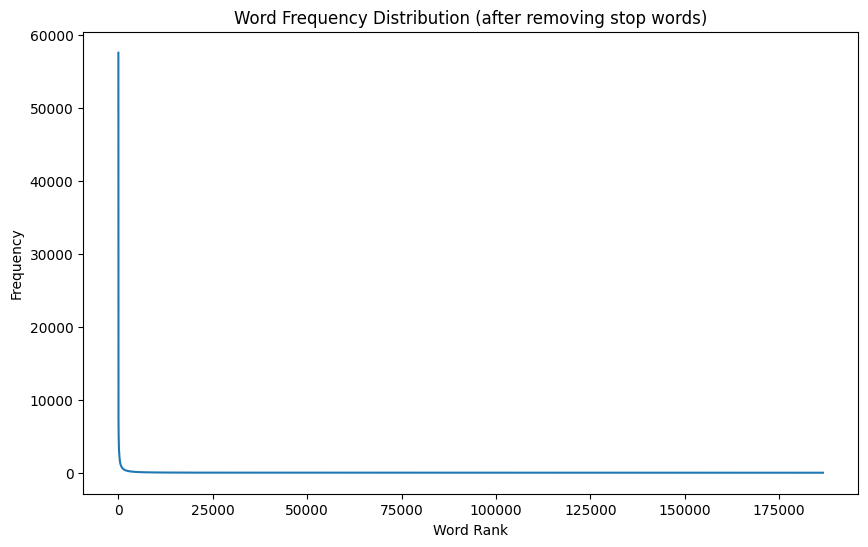

Average Text Length (after removing stop words): 59.52768945416004


In [27]:
from collections import Counter
import itertools
import matplotlib.pyplot as plt

# Tokenize the text data into words
all_words = list(itertools.chain.from_iterable([text.split() for text in X_train]))

# Vocabulary size
vocab_size = len(set(all_words))
print("Vocabulary Size (after removing stop words):", vocab_size)

# Word frequency distribution
word_counts = Counter(all_words)
print("Most Common Words (after removing stop words):", word_counts.most_common(10))

# Plot word frequency distribution
word_frequencies = [count for _, count in word_counts.most_common()]
plt.figure(figsize=(10, 6))
plt.plot(word_frequencies)
plt.title("Word Frequency Distribution (after removing stop words)")
plt.xlabel("Word Rank")
plt.ylabel("Frequency")
plt.show()

# Average text length
text_lengths = [len(text.split()) for text in X_train_no_stopwords]
print("Average Text Length (after removing stop words):", sum(text_lengths) / len(text_lengths))

## Use SMOTE and run it through the best model

Class distribution after SMOTE resampling: Counter({np.int64(12): 8167, np.int64(0): 8167, np.int64(13): 8167, np.int64(7): 8167, np.int64(17): 8167, np.int64(14): 8167, np.int64(3): 8167, np.int64(23): 8167, np.int64(18): 8167, np.int64(5): 8167, np.int64(11): 8167, np.int64(24): 8167, np.int64(19): 8167, np.int64(4): 8167, np.int64(9): 8167, np.int64(16): 8167, np.int64(21): 8167, np.int64(22): 8167, np.int64(26): 8167, np.int64(15): 8167, np.int64(25): 8167, np.int64(1): 8167, np.int64(6): 8167, np.int64(20): 8167, np.int64(10): 8167, np.int64(8): 8167, np.int64(2): 8167})
Classification Report on Test Set:
              precision    recall  f1-score   support

          10       0.32      0.51      0.39       623
          40       0.57      0.53      0.55       502
          50       0.74      0.81      0.77       336
          60       0.88      0.83      0.85       166
        1140       0.69      0.74      0.71       534
        1160       0.89      0.84      0.86       791
   

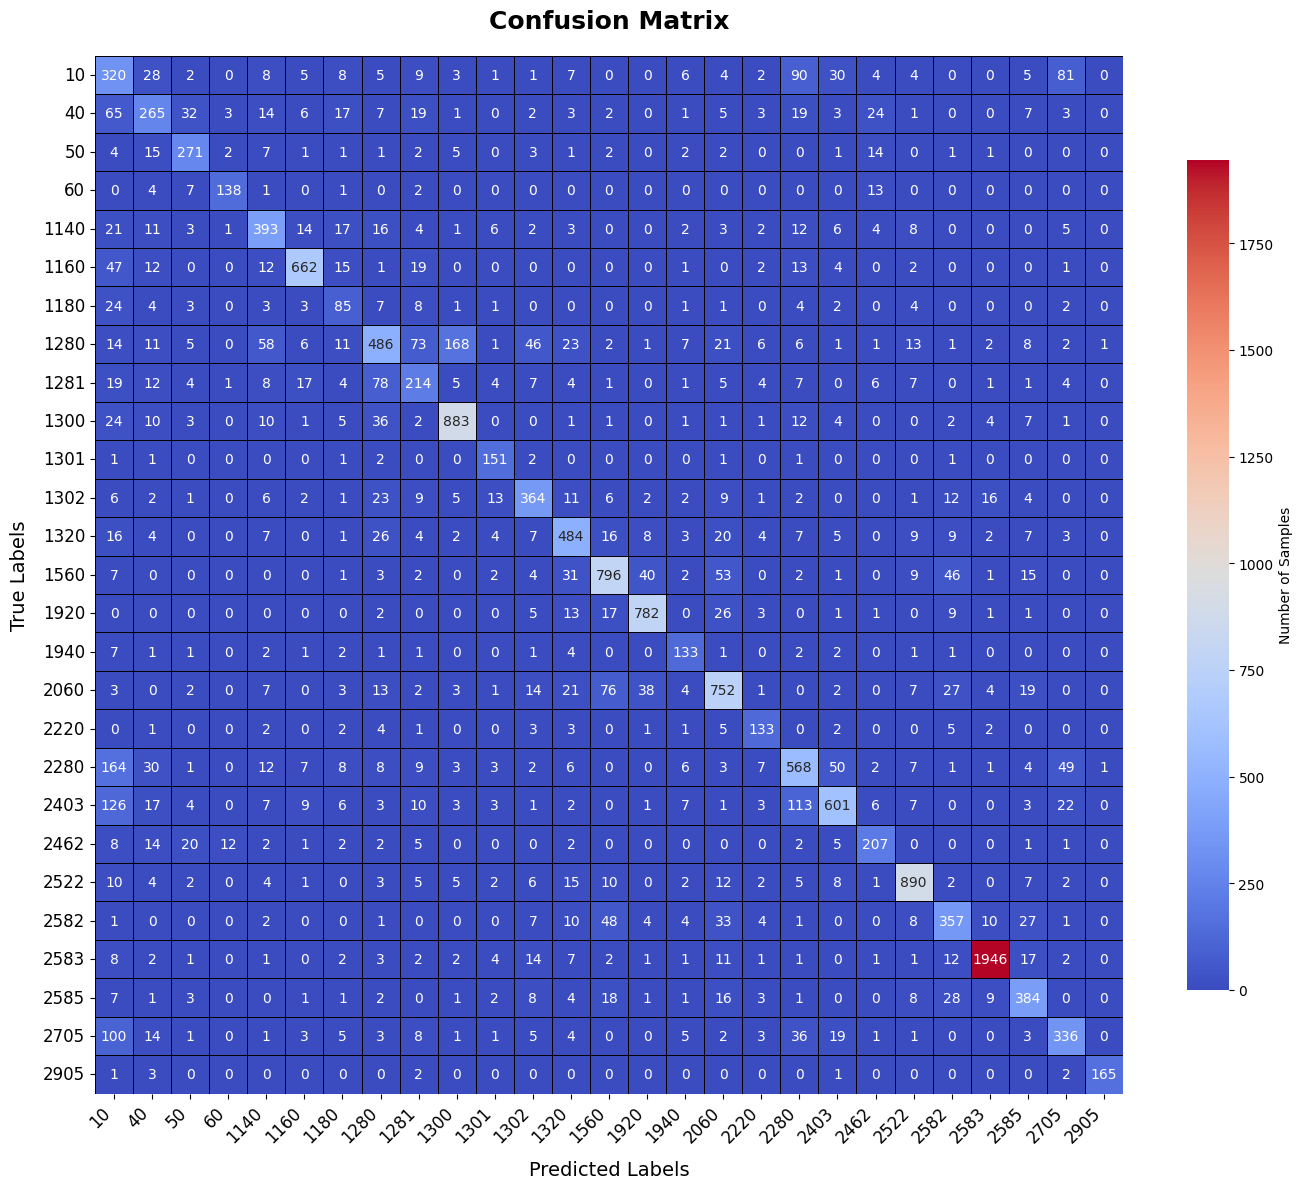

In [5]:
from imblearn.over_sampling import SMOTE
from sklearn.svm import SVC
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder
from collections import Counter

# Step 1: Encode the labels
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

# Step 2: Vectorize the training and test data
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 1))
X_train_vectorized = vectorizer.fit_transform(X_train)
X_test_vectorized = vectorizer.transform(X_test)

# Step 3: Apply SMOTETomek for resampling
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_vectorized, y_train_encoded)

# Check the class distribution after resampling
print("Class distribution after SMOTE resampling:", Counter(y_train_resampled))

# Step 4: Train the SVM model with the specified parameters
best_svm = SVC(C=1, kernel='linear', random_state=42)
best_svm.fit(X_train_resampled, y_train_resampled)

# Step 5: Predict on the test set
y_test_pred_encoded = best_svm.predict(X_test_vectorized)

# Step 6: Decode the predicted labels back to the original class labels
y_test_pred = label_encoder.inverse_transform(y_test_pred_encoded)

# Step 7: Evaluate the model
print("Classification Report on Test Set:")
print(classification_report(y_test, y_test_pred))

# Step 8: Generate and display the confusion matrix
cm = confusion_matrix(y_test, y_test_pred)
print("Confusion Matrix:")
print(cm)

# Optional: Visualize the confusion matrix
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 12))
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='coolwarm', 
    xticklabels=label_encoder.classes_, 
    yticklabels=label_encoder.classes_,
    linewidths=0.5, 
    linecolor='black', 
    cbar_kws={'shrink': 0.8, 'label': 'Number of Samples'}
)
plt.title('Confusion Matrix', fontsize=18, weight='bold', pad=20)
plt.xlabel('Predicted Labels', fontsize=14, labelpad=10)
plt.ylabel('True Labels', fontsize=14, labelpad=10)
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(rotation=0, fontsize=12)
plt.tight_layout()
plt.show()

## Re-Run of best Code with stratified train/test split (without Weighted classes in classifier)

In [ ]:
"""THIS IS THE FINAL COPY OF THE MOST MINIMALISTIC VERSION OF THE GRIDSEARCH WITHOUT RESAMPLING,
WITH ALL 4 CLASSIFIERS (LOGREG, SVM, RF, XGB)."""

#ISSUES SOLVED:
# 1. Random Forrest:
# max_depth = None increased computation cost significantly
# max_depth = None 

# 2. SVM:
# rbf kernel increased computation cost significantly (aborted 3 run after 90 mins). 
# Therefore only linear kernel is used.

# 137 min VSCode 07.05.2025
# Best Parameters: {'classifier': SVC(random_state=42), 'classifier__C': 1, 'classifier__kernel': 'linear', 'vectorizer': TfidfVectorizer(), 'vectorizer__max_features': 5000, 'vectorizer__ngram_range': (1, 1)}
# Best Cross-Validation Score: 0.7520994552406278
# Test Set Weighted F1 Score: 0.76

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report

# Encode the labels
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

# Define the pipeline
pipeline = Pipeline([
    ('vectorizer', CountVectorizer()),  # Placeholder for vectorizer
    ('classifier', RandomForestClassifier(random_state=42))  # Placeholder for classifier
])

# Define the parameter grid
param_grid = [
    # Random Forest parameters
    {
        'vectorizer': [CountVectorizer(), TfidfVectorizer()],  # Test both vectorizers
        'vectorizer__max_features': [5000],  # Limit vocabulary size
        'vectorizer__ngram_range': [(1, 1)],  # Use unigrams
        'classifier': [RandomForestClassifier(random_state=42)],  # Random Forest
        'classifier__n_estimators': [50, 100],  # Number of trees
        'classifier__max_depth': [10, 20],  # Maximum depth of trees
    },
    # Logistic Regression parameters
    {
        'vectorizer': [CountVectorizer(), TfidfVectorizer()],  # Test both vectorizers
        'vectorizer__max_features': [5000],  # Limit vocabulary size
        'vectorizer__ngram_range': [(1, 1)],  # Use unigrams
        'classifier': [LogisticRegression(random_state=42, max_iter=1000)],  # Logistic Regression
        'classifier__C': [0.1, 1, 10],  # Regularization strength
        'classifier__penalty': ['l2'],  # Regularization type
    },
    # SVM parameters
    {
        'vectorizer': [CountVectorizer(), TfidfVectorizer()],  # Test both vectorizers
        'vectorizer__max_features': [5000],  # Limit vocabulary size
        'vectorizer__ngram_range': [(1, 1)],  # Use unigrams
        'classifier': [SVC(random_state=42)],  # SVM
        'classifier__C': [0.1, 1, 10],  # Regularization strength
        'classifier__kernel': ['linear'],  # Kernel type
    },
    # XGBoost parameters
    {
        'vectorizer': [CountVectorizer(), TfidfVectorizer()],  # Test both vectorizers
        'vectorizer__max_features': [5000],  # Limit vocabulary size
        'vectorizer__ngram_range': [(1, 1)],  # Use unigrams
        'classifier': [XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')],  # XGBoost
        'classifier__n_estimators': [50],  # Number of boosting rounds
        'classifier__max_depth': [3],  # Maximum depth of trees
        'classifier__learning_rate': [0.1],  # Learning rate
    }
]

# Perform grid search with weighted F1 score
grid_search = GridSearchCV(
    pipeline,
    param_grid,
    scoring='f1_weighted',  # Use weighted F1 score for evaluation
    cv=3,  # Use 3-fold cross-validation for faster computation
    n_jobs=-1  # Use all available CPU cores
)

# Fit the grid search
grid_search.fit(X_train, y_train_encoded)

# Print the best parameters and score
print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Validation Score:", grid_search.best_score_)

# Predict on the test set
y_test_pred_encoded = grid_search.best_estimator_.predict(X_test)

# Decode the predicted labels back to the original class labels
y_test_pred = label_encoder.inverse_transform(y_test_pred_encoded)

# Generate a classification report
print("Classification Report on Test Set:")
print(classification_report(y_test, y_test_pred))

/Users/robertwilson/Documents/GitHub/feb25_bds_classification-of-rakuten-e-commerce-products/myenv/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [13:59:47] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/robertwilson/Documents/GitHub/feb25_bds_classification-of-rakuten-e-commerce-products/myenv/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [13:59:48] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/robertwilson/Documents/GitHub/feb25_bds_classification-of-rakuten-e-commerce-products/myenv/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [13:59:49] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i,

Best Parameters: {'classifier': SVC(random_state=42), 'classifier__C': 1, 'classifier__kernel': 'linear', 'vectorizer': TfidfVectorizer(), 'vectorizer__max_features': 5000, 'vectorizer__ngram_range': (1, 1)}
Best Cross-Validation Score: 0.7520994552406278
Classification Report on Test Set:
              precision    recall  f1-score   support

          10       0.31      0.54      0.39       623
          40       0.65      0.54      0.59       502
          50       0.78      0.75      0.77       336
          60       0.96      0.78      0.86       166
        1140       0.75      0.74      0.74       534
        1160       0.88      0.86      0.87       791
        1180       0.69      0.37      0.48       153
        1280       0.63      0.57      0.60       974
        1281       0.70      0.44      0.54       414
        1300       0.80      0.89      0.84      1009
        1301       0.92      0.91      0.91       161
        1302       0.79      0.68      0.73       498
      

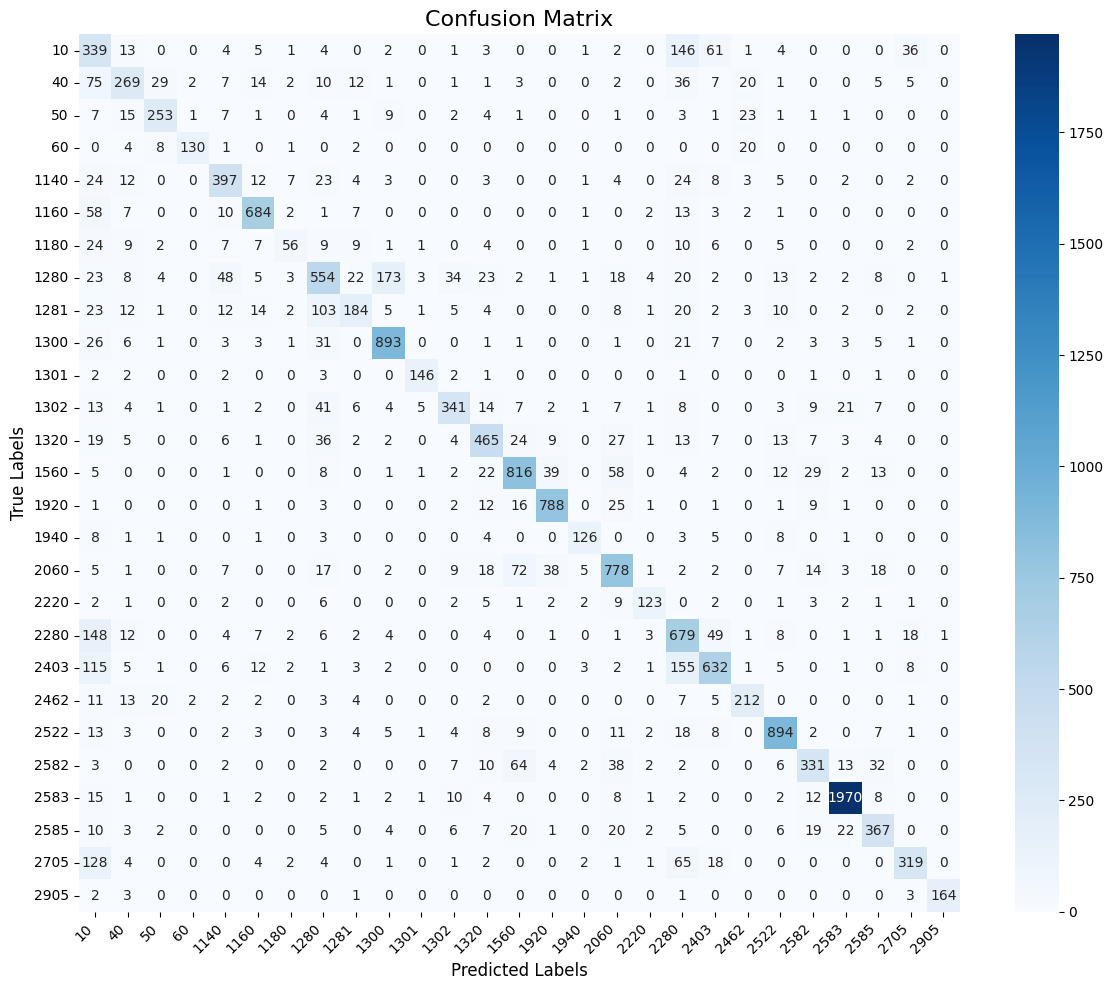

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define the class labels
class_labels = [
    "10", "40", "50", "60", "1140", "1160", "1180", "1280", "1281", "1300", "1301", "1302", "1320", "1560",
    "1920", "1940", "2060", "2220", "2280", "2403", "2462", "2522", "2582", "2583", "2585", "2705", "2905"
]

# Create a heatmap for the confusion matrix
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix', fontsize=16)
plt.xlabel('Predicted Labels', fontsize=12)
plt.ylabel('True Labels', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()

# Show the plot
plt.show()

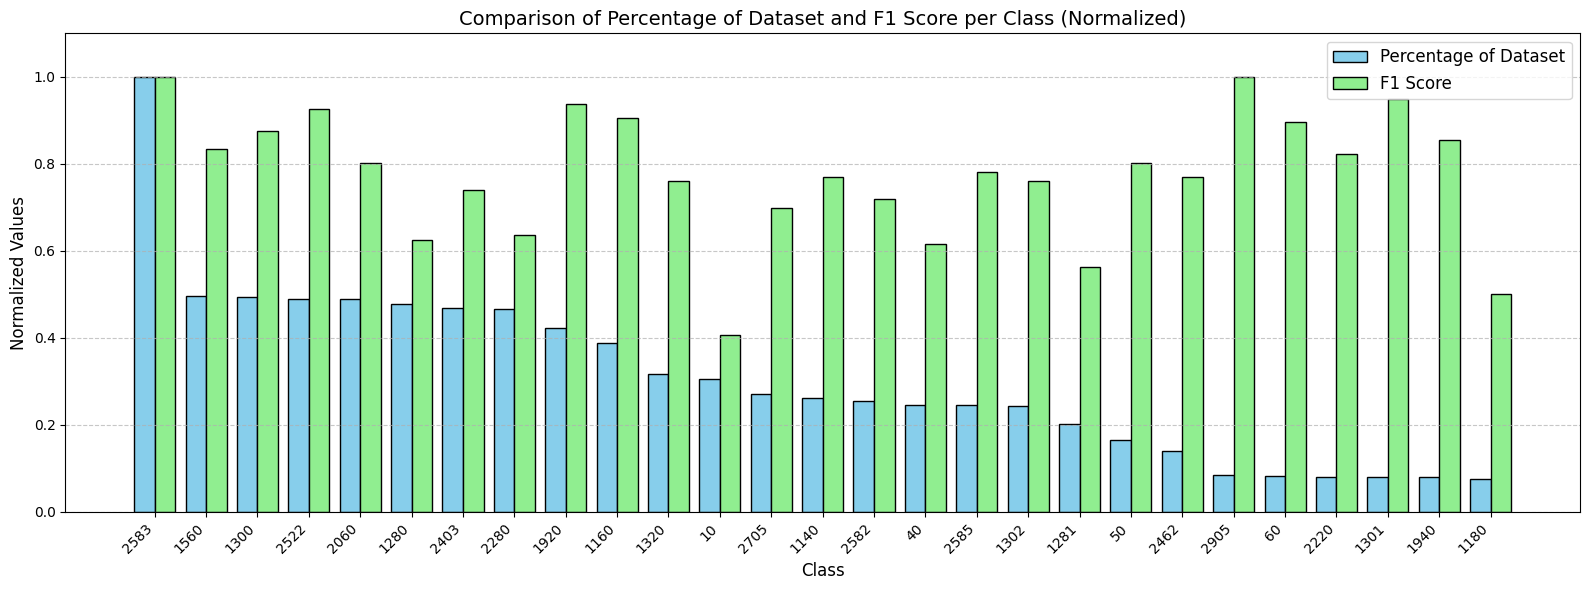

In [11]:
import matplotlib.pyplot as plt
import numpy as np

# Data for the plot
classes = [
    "10", "40", "50", "60", "1140", "1160", "1180", "1280", "1281", "1300", "1301", "1302", "1320", "1560",
    "1920", "1940", "2060", "2220", "2280", "2403", "2462", "2522", "2582", "2583", "2585", "2705", "2905"
]
percentages = [
    3.67, 2.95, 1.98, 0.98, 3.15, 4.66, 0.90, 5.74, 2.44, 5.94, 0.95, 2.93, 3.82,
    5.97, 5.07, 0.95, 5.88, 0.97, 5.61, 5.62, 1.67, 5.88, 3.05, 12.02, 2.94, 3.25, 1.03
]
f1_scores = [
    0.39, 0.59, 0.77, 0.86, 0.74, 0.87, 0.48, 0.60, 0.54, 0.84, 0.91, 0.73, 0.73,
    0.80, 0.90, 0.82, 0.77, 0.79, 0.61, 0.71, 0.74, 0.89, 0.69, 0.96, 0.75, 0.67, 0.96
]

# Sort the data by percentages
sorted_data = sorted(zip(percentages, f1_scores, classes), reverse=True)  # Sort by percentages in descending order
percentages, f1_scores, classes = zip(*sorted_data)  # Unzip the sorted data

# Normalize the data
percentages_normalized = [p / max(percentages) for p in percentages]  # Normalize percentages to [0, 1]
f1_scores_normalized = [f / max(f1_scores) for f in f1_scores]        # F1 scores are already in [0, 1]

# Create the grouped bar chart
x = np.arange(len(classes))  # The label locations
width = 0.4  # Width of the bars

plt.figure(figsize=(16, 6))
plt.bar(x - width/2, percentages_normalized, width, label='Percentage of Dataset', color='skyblue', edgecolor='black')
plt.bar(x + width/2, f1_scores_normalized, width, label='F1 Score', color='lightgreen', edgecolor='black')

# Add labels, title, and legend
plt.title('Comparison of Percentage of Dataset and F1 Score per Class (Normalized)', fontsize=14)
plt.xlabel('Class', fontsize=12)
plt.ylabel('Normalized Values', fontsize=12)
plt.xticks(x, classes, rotation=45, fontsize=10, ha='right')  # Rotate and align labels
plt.ylim(0, 1.1)  # Extend y-axis slightly above 1 for better visibility
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(fontsize=12)
plt.tight_layout()

# Show the plot
plt.show()

In [12]:
import numpy as np

# Calculate the Pearson correlation coefficient
correlation = np.corrcoef(percentages, f1_scores)[0, 1]
print(f"Pearson Correlation Coefficient: {correlation:.2f}")

Pearson Correlation Coefficient: 0.19


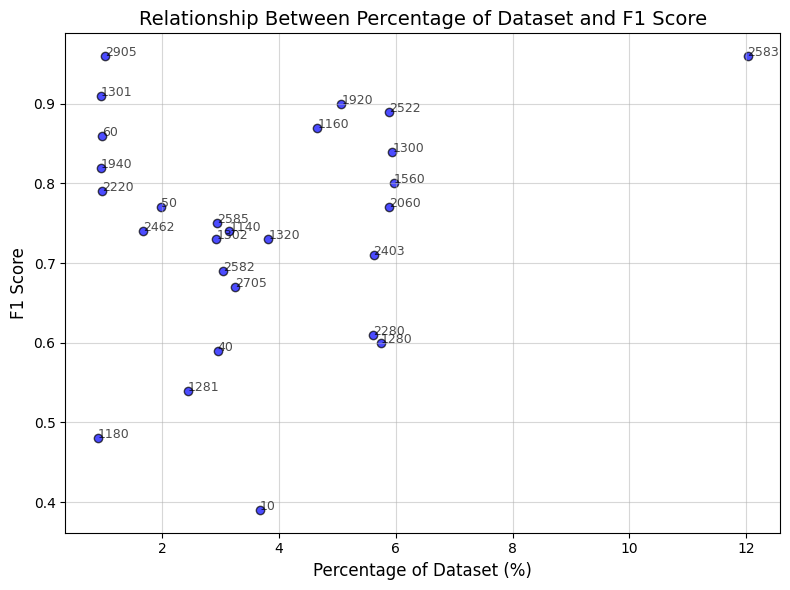

In [13]:
import matplotlib.pyplot as plt

# Create a scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(percentages, f1_scores, color='blue', edgecolor='black', alpha=0.7)
plt.title('Relationship Between Percentage of Dataset and F1 Score', fontsize=14)
plt.xlabel('Percentage of Dataset (%)', fontsize=12)
plt.ylabel('F1 Score', fontsize=12)
plt.grid(alpha=0.5)
plt.tight_layout()

# Annotate points with class labels
for i, cls in enumerate(classes):
    plt.annotate(cls, (percentages[i], f1_scores[i]), fontsize=9, alpha=0.7)

plt.show()

## Pipeline including Class Weight

In [ ]:
# 334 min. VSCode 07.05.2025
# Best Parameters: {'classifier': SVC(class_weight='balanced', random_state=42), 'classifier__C': 1, 'classifier__kernel': 'linear', 'vectorizer': TfidfVectorizer(), 'vectorizer__max_features': 5000, 'vectorizer__ngram_range': (1, 1)}
# Best Cross-Validation Score: 0.7494348509252465
# Test Set Weighted F1 Score: 0.75

# Added Class Weights:
# RF, LR, SVM: ='balanced' to handle class imbalance
# XGB: scale_pos_weight=1

#ISSUES SOLVED:

# 1. Random Forrest:
# max_depth = None increased computation cost significantly
# max_depth = None 

# 2. SVM:
# rbf kernel increased computation cost significantly (aborted execution after 90 mins). 
# Therefore only linear kernel is used.

# 3. XGBoost:
# LabelEncoder was used to encode the labels before fitting the model.

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

# Encode the labels
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

# Define the pipeline
pipeline = Pipeline([
    ('vectorizer', CountVectorizer()),  # Placeholder for vectorizer
    ('classifier', RandomForestClassifier(random_state=42))  # Placeholder for classifier
])

# Define the parameter grid
param_grid = [
    # Random Forest parameters
    {
        'vectorizer': [CountVectorizer(), TfidfVectorizer()],
        'vectorizer__max_features': [5000],
        'vectorizer__ngram_range': [(1, 1)],
        'classifier': [RandomForestClassifier(random_state=42, class_weight='balanced')],
        'classifier__n_estimators': [50, 100],
        'classifier__max_depth': [10, 20],
    },
    # Logistic Regression parameters
    {
        'vectorizer': [CountVectorizer(), TfidfVectorizer()],
        'vectorizer__max_features': [5000],
        'vectorizer__ngram_range': [(1, 1)],
        'classifier': [LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')],
        'classifier__C': [0.1, 1, 10],
        'classifier__penalty': ['l2'],
    },
    # SVM parameters
    {
        'vectorizer': [CountVectorizer(), TfidfVectorizer()],
        'vectorizer__max_features': [5000],
        'vectorizer__ngram_range': [(1, 1)],
        'classifier': [SVC(random_state=42, class_weight='balanced')],
        'classifier__C': [0.1, 1, 10],
        'classifier__kernel': ['linear'],
    },
    # XGBoost parameters
    {
        'vectorizer': [CountVectorizer(), TfidfVectorizer()],
        'vectorizer__max_features': [5000],
        'vectorizer__ngram_range': [(1, 1)],
        'classifier': [XGBClassifier(random_state=42, scale_pos_weight=1, use_label_encoder=False, eval_metric='logloss')],
        'classifier__n_estimators': [50, 100],
        'classifier__max_depth': [3, 5],
        'classifier__learning_rate': [0.01, 0.1],
    }
]

# Perform grid search with the encoded labels
grid_search = GridSearchCV(
    pipeline,
    param_grid,
    scoring='f1_weighted',
    cv=3,
    n_jobs=-1
)

# Fit the grid search
grid_search.fit(X_train, y_train_encoded)

# Print the best parameters and best cross-validation score
print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Validation Score:", grid_search.best_score_)

# Predict on the test set
y_test_pred_encoded = grid_search.best_estimator_.predict(X_test)

# Decode the predicted labels back to the original class labels
y_test_pred = label_encoder.inverse_transform(y_test_pred_encoded)

# Generate a classification report
print("Classification Report on Test Set:")
print(classification_report(y_test, y_test_pred))

/Users/robertwilson/Documents/GitHub/feb25_bds_classification-of-rakuten-e-commerce-products/myenv/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [04:12:54] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "scale_pos_weight", "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/robertwilson/Documents/GitHub/feb25_bds_classification-of-rakuten-e-commerce-products/myenv/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [04:13:02] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "scale_pos_weight", "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/robertwilson/Documents/GitHub/feb25_bds_classification-of-rakuten-e-commerce-products/myenv/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [04:13:04] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "scale_pos_weight", "use_label

Best Parameters: {'classifier': SVC(class_weight='balanced', random_state=42), 'classifier__C': 1, 'classifier__kernel': 'linear', 'vectorizer': TfidfVectorizer(), 'vectorizer__max_features': 5000, 'vectorizer__ngram_range': (1, 1)}
Best Cross-Validation Score: 0.7494348509252465
Classification Report on Test Set:
              precision    recall  f1-score   support

          10       0.31      0.69      0.43       612
          40       0.55      0.53      0.54       521
          50       0.75      0.78      0.76       357
          60       0.89      0.89      0.89       161
        1140       0.66      0.75      0.70       539
        1160       0.91      0.82      0.86       786
        1180       0.35      0.54      0.42       146
        1280       0.68      0.44      0.54       961
        1281       0.55      0.54      0.55       424
        1300       0.81      0.86      0.83       974
        1301       0.82      0.89      0.85       169
        1302       0.74      0.75  

## Pipeline including Resampling: SMOTETomek

In [ ]:
# Aborted after +6 hrs. in VSCode 06.05.2025

# Define the pipeline. 
# Ensuring that resampling is applied only to the training folds during cross-validation
# Preventing data leakage into the validation folds.

pipeline = Pipeline([
    ('vectorizer', 'passthrough'), # Placeholder for vectorizer
    ('resampler', SMOTETomek(random_state=42)),  # Resampling step
    ('classifier', RandomForestClassifier(random_state=42))  # Classifier
])

param_grid = {
    'vectorizer': [TfidfVectorizer(), CountVectorizer()],  # Test both vectorizers
    'vectorizer__max_features': [5000], # Limit vocabulary size
    'vectorizer__ngram_range': [(1, 1)], # Use unigrams
    'classifier__n_estimators': [50, 100], # Number of trees in Random Forest
    'classifier__max_depth': [10, 20], # Maximum depth of trees
}

# Perform grid search with cross-validation
grid_search = GridSearchCV(
    pipeline,
    param_grid,
    scoring='f1_weighted',  # Use weighted F1 score for imbalanced datasets
    cv=3,  # 3-fold cross-validation
    n_jobs=-1  # Use all available cores
)

# Fit the grid search on the original training data
grid_search.fit(X_train, y_train)

# Print the best parameters and score
print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Validation Score:", grid_search.best_score_)


KeyboardInterrupt: 

In [ ]:
from sklearn.metrics import classification_report

# Predict on the test set using the best model
y_test_pred = grid_search.best_estimator_.predict(X_test)

# Generate a classification report
print("Classification Report on Test Set:")
print(classification_report(y_test, y_test_pred))

# BEFORE RESAMPLING

## Pipeline

In [ ]:
"""THIS IS THE FINAL COPY OF THE MOST MINIMALISTIC VERSION OF THE GRIDSEARCH WITHOUT RESAMPLING,
WITH ALL 4 CLASSIFIERS (LOGREG, SVM, RF, XGB)."""

"""ERROR IN XGBOOST: XGBoost expects the target variable (y) to contain consecutive integer labels"""

#ISSUES SOLVED:
# 1. Random Forrest:
# max_depth = None increased computation cost significantly
# max_depth = None 

# 2. SVM:
# rbf kernel increased computation cost significantly (aborted 3 run after 90 mins). 
# Therefore only linear kernel is used.

# 196 min VSCode 07.05.2025
# Best Parameters: {'classifier': SVC(random_state=42), 'classifier__C': 1, 'classifier__kernel': 'linear', 'vectorizer': TfidfVectorizer(), 'vectorizer__max_features': 5000, 'vectorizer__ngram_range': (1, 1)}
# Best Cross-Validation Score: 0.7545163737197887
# Test Set Weighted F1 Score: 0.76

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report

# Encode the labels
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

# Define the pipeline
pipeline = Pipeline([
    ('vectorizer', CountVectorizer()),  # Placeholder for vectorizer
    ('classifier', RandomForestClassifier(random_state=42))  # Placeholder for classifier
])

# Define the parameter grid
param_grid = [
    # Random Forest parameters
    {
        'vectorizer': [CountVectorizer(), TfidfVectorizer()],  # Test both vectorizers
        'vectorizer__max_features': [5000],  # Limit vocabulary size
        'vectorizer__ngram_range': [(1, 1)],  # Use unigrams
        'classifier': [RandomForestClassifier(random_state=42)],  # Random Forest
        'classifier__n_estimators': [50, 100],  # Number of trees
        'classifier__max_depth': [10, 20],  # Maximum depth of trees
    },
    # Logistic Regression parameters
    {
        'vectorizer': [CountVectorizer(), TfidfVectorizer()],  # Test both vectorizers
        'vectorizer__max_features': [5000],  # Limit vocabulary size
        'vectorizer__ngram_range': [(1, 1)],  # Use unigrams
        'classifier': [LogisticRegression(random_state=42, max_iter=1000)],  # Logistic Regression
        'classifier__C': [0.1, 1, 10],  # Regularization strength
        'classifier__penalty': ['l2'],  # Regularization type
    },
    # SVM parameters
    {
        'vectorizer': [CountVectorizer(), TfidfVectorizer()],  # Test both vectorizers
        'vectorizer__max_features': [5000],  # Limit vocabulary size
        'vectorizer__ngram_range': [(1, 1)],  # Use unigrams
        'classifier': [SVC(random_state=42)],  # SVM
        'classifier__C': [0.1, 1, 10],  # Regularization strength
        'classifier__kernel': ['linear'],  # Kernel type
    },
    # XGBoost parameters
    {
        'vectorizer': [CountVectorizer(), TfidfVectorizer()],  # Test both vectorizers
        'vectorizer__max_features': [5000],  # Limit vocabulary size
        'vectorizer__ngram_range': [(1, 1)],  # Use unigrams
        'classifier': [XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')],  # XGBoost
        'classifier__n_estimators': [50],  # Number of boosting rounds
        'classifier__max_depth': [3],  # Maximum depth of trees
        'classifier__learning_rate': [0.1],  # Learning rate
    }
]

# Perform grid search with weighted F1 score
grid_search = GridSearchCV(
    pipeline,
    param_grid,
    scoring='f1_weighted',  # Use weighted F1 score for evaluation
    cv=3,  # Use 3-fold cross-validation for faster computation
    n_jobs=-1  # Use all available CPU cores
)

# Fit the grid search
grid_search.fit(X_train, y_train_encoded)

# Print the best parameters and score
print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Validation Score:", grid_search.best_score_)

# Predict on the test set
y_test_pred_encoded = grid_search.best_estimator_.predict(X_test)

# Decode the predicted labels back to the original class labels
y_test_pred = label_encoder.inverse_transform(y_test_pred_encoded)

# Generate a classification report
print("Classification Report on Test Set:")
print(classification_report(y_test, y_test_pred))

/Users/robertwilson/Documents/GitHub/feb25_bds_classification-of-rakuten-e-commerce-products/myenv/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [23:41:24] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/robertwilson/Documents/GitHub/feb25_bds_classification-of-rakuten-e-commerce-products/myenv/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [23:50:03] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/robertwilson/Documents/GitHub/feb25_bds_classification-of-rakuten-e-commerce-products/myenv/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [23:50:07] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i,

Best Parameters: {'classifier': SVC(random_state=42), 'classifier__C': 1, 'classifier__kernel': 'linear', 'vectorizer': TfidfVectorizer(), 'vectorizer__max_features': 5000, 'vectorizer__ngram_range': (1, 1)}
Best Cross-Validation Score: 0.7545163737197887
Classification Report on Test Set:
              precision    recall  f1-score   support

          10       0.32      0.59      0.42       612
          40       0.62      0.52      0.57       521
          50       0.79      0.76      0.78       357
          60       0.94      0.87      0.90       161
        1140       0.69      0.74      0.71       539
        1160       0.87      0.84      0.86       786
        1180       0.67      0.45      0.54       146
        1280       0.62      0.54      0.58       961
        1281       0.64      0.44      0.53       424
        1300       0.80      0.87      0.84       974
        1301       0.88      0.84      0.86       169
        1302       0.78      0.73      0.75       507
      

In [6]:
"""THIS IS ANOTHER COPY OF THE MOST MINIMALISTIC VERSION OF THE GRIDSEARCH WITHOUT RESAMPLING,
ADDING A SVM MODEL ONTOP OF THE LOGISTIC REGRGRESSION CLASSIFIER."""

# Having a rbf kernel in SVM increased computation time significantly (aborted after 90 mins). 
# Therefore only linear kernel is used.

# 36 min VSCode 07.05.2025
# Best Parameters: {'classifier': SVC(random_state=42), 'classifier__C': 1, 'classifier__kernel': 'linear', 'vectorizer': TfidfVectorizer(), 'vectorizer__max_features': 5000, 'vectorizer__ngram_range': (1, 1)}
# Best Cross-Validation Score: 0.7545163737197887
# Test Set Weighted F1 Score: 0.76

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

# Define the pipeline
pipeline = Pipeline([
    ('vectorizer', CountVectorizer()),  # Placeholder for vectorizer
    ('classifier', RandomForestClassifier(random_state=42))  # Placeholder for classifier
])

# Define the parameter grid
param_grid = [
    # Random Forest parameters
    {
        'vectorizer': [CountVectorizer(), TfidfVectorizer()],  # Test both vectorizers
        'vectorizer__max_features': [5000],  # Limit vocabulary size
        'vectorizer__ngram_range': [(1, 1)],  # Use unigrams
        'classifier': [RandomForestClassifier(random_state=42)],  # Random Forest
        'classifier__n_estimators': [50, 100],  # Number of trees
        'classifier__max_depth': [10, 20],  # Maximum depth of trees
    },
    # Logistic Regression parameters
    {
        'vectorizer': [CountVectorizer(), TfidfVectorizer()],  # Test both vectorizers
        'vectorizer__max_features': [5000],  # Limit vocabulary size
        'vectorizer__ngram_range': [(1, 1)],  # Use unigrams
        'classifier': [LogisticRegression(random_state=42, max_iter=1000)],  # Logistic Regression
        'classifier__C': [0.1, 1, 10],  # Regularization strength
        'classifier__penalty': ['l2'],  # Regularization type
    },
    # SVM parameters
    {
        'vectorizer': [CountVectorizer(), TfidfVectorizer()],  # Test both vectorizers
        'vectorizer__max_features': [5000],  # Limit vocabulary size
        'vectorizer__ngram_range': [(1, 1)],  # Use unigrams
        'classifier': [SVC(random_state=42)],  # SVM
        'classifier__C': [0.1, 1, 10],  # Regularization strength
        'classifier__kernel': ['linear'],  # Kernel type
    }
]

# Perform grid search with weighted F1 score
grid_search = GridSearchCV(
    pipeline,
    param_grid,
    scoring='f1_weighted',  # Use weighted F1 score for evaluation
    cv=3,  # Use 3-fold cross-validation for faster computation
    n_jobs=-1  # Use all available CPU cores
)

# Fit the grid search on the training data
grid_search.fit(X_train, y_train)

# Print the best parameters and score
print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Validation Score:", grid_search.best_score_)

# Predict on the test set using the best model
y_test_pred = grid_search.best_estimator_.predict(X_test)

# Generate a classification report
print("Classification Report on Test Set:")
print(classification_report(y_test, y_test_pred))

Best Parameters: {'classifier': SVC(random_state=42), 'classifier__C': 1, 'classifier__kernel': 'linear', 'vectorizer': TfidfVectorizer(), 'vectorizer__max_features': 5000, 'vectorizer__ngram_range': (1, 1)}
Best Cross-Validation Score: 0.7545163737197887
Classification Report on Test Set:


NameError: name 'classification_report' is not defined

In [7]:
from sklearn.metrics import classification_report

# Generate a classification report
print("Classification Report on Test Set:")
print(classification_report(y_test, y_test_pred))

Classification Report on Test Set:
              precision    recall  f1-score   support

          10       0.32      0.59      0.42       612
          40       0.62      0.52      0.57       521
          50       0.79      0.76      0.78       357
          60       0.94      0.87      0.90       161
        1140       0.69      0.74      0.71       539
        1160       0.87      0.84      0.86       786
        1180       0.67      0.45      0.54       146
        1280       0.62      0.54      0.58       961
        1281       0.64      0.44      0.53       424
        1300       0.80      0.87      0.84       974
        1301       0.88      0.84      0.86       169
        1302       0.78      0.73      0.75       507
        1320       0.74      0.68      0.71       672
        1560       0.77      0.78      0.78      1013
        1920       0.88      0.92      0.90       841
        1940       0.83      0.80      0.81       137
        2060       0.77      0.77      0.77   

In [ ]:
"""THIS IS ANOTHER COPY OF THE MOST MINIMALISTIC VERSION OF THE GRIDSEARCH WITHOUT RESAMPLING,
ADDING A LOGISTIC REGRGRESSION CLASSIFIER."""

# 3 min VSCode 07.05.2025
# Best Parameters: {'classifier': LogisticRegression(max_iter=1000, random_state=42), 'classifier__C': 10, 'classifier__penalty': 'l2', 'vectorizer': TfidfVectorizer(), 'vectorizer__max_features': 5000, 'vectorizer__ngram_range': (1, 1)}
# Best Cross-Validation Score: 0.7459191794340155
# Test Set Weighted F1 Score: 0.75
 
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

# Define the pipeline
pipeline = Pipeline([
    ('vectorizer', CountVectorizer()),  # Placeholder for vectorizer
    ('classifier', RandomForestClassifier(random_state=42))  # Placeholder for classifier
])

# Define the parameter grid
param_grid = [
    # Random Forest parameters
    {
        'vectorizer': [CountVectorizer(), TfidfVectorizer()],  # Test both vectorizers
        'vectorizer__max_features': [5000],  # Limit vocabulary size
        'vectorizer__ngram_range': [(1, 1)],  # Use unigrams
        'classifier': [RandomForestClassifier(random_state=42)],  # Random Forest
        'classifier__n_estimators': [50, 100],  # Number of trees
        'classifier__max_depth': [10, 20],  # Maximum depth of trees
    },
    # Logistic Regression parameters
    {
        'vectorizer': [CountVectorizer(), TfidfVectorizer()],  # Test both vectorizers
        'vectorizer__max_features': [5000],  # Limit vocabulary size
        'vectorizer__ngram_range': [(1, 1)],  # Use unigrams
        'classifier': [LogisticRegression(random_state=42, max_iter=1000)],  # Logistic Regression
        'classifier__C': [0.1, 1, 10],  # Regularization strength
        'classifier__penalty': ['l2'],  # Regularization type
    }
]

# Perform grid search with weighted F1 score
grid_search = GridSearchCV(
    pipeline,
    param_grid,
    scoring='f1_weighted',  # Use weighted F1 score for evaluation
    cv=3,  # Use 3-fold cross-validation for faster computation
    n_jobs=-1  # Use all available CPU cores
)

# Fit the grid search on the training data
grid_search.fit(X_train, y_train)

# Print the best parameters and score
print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Validation Score:", grid_search.best_score_)

Best Parameters: {'classifier': LogisticRegression(max_iter=1000, random_state=42), 'classifier__C': 10, 'classifier__penalty': 'l2', 'vectorizer': TfidfVectorizer(), 'vectorizer__max_features': 5000, 'vectorizer__ngram_range': (1, 1)}
Best Cross-Validation Score: 0.7459191794340155


In [9]:
from sklearn.metrics import classification_report

# Predict on the test set using the best model
y_test_pred = grid_search.best_estimator_.predict(X_test)

# Generate a classification report
print("Classification Report on Test Set:")
print(classification_report(y_test, y_test_pred))

Classification Report on Test Set:
              precision    recall  f1-score   support

          10       0.35      0.51      0.41       612
          40       0.61      0.55      0.58       521
          50       0.79      0.74      0.76       357
          60       0.89      0.88      0.88       161
        1140       0.68      0.72      0.70       539
        1160       0.85      0.83      0.84       786
        1180       0.58      0.47      0.52       146
        1280       0.60      0.55      0.57       961
        1281       0.54      0.43      0.48       424
        1300       0.78      0.84      0.81       974
        1301       0.89      0.85      0.87       169
        1302       0.78      0.73      0.75       507
        1320       0.75      0.68      0.71       672
        1560       0.77      0.78      0.78      1013
        1920       0.89      0.91      0.90       841
        1940       0.76      0.80      0.78       137
        2060       0.76      0.76      0.76   

In [ ]:
""" 2ND COPY OF THE CELL BELOW WITH EVEN SMALLER SEARCH SPACE (HYPERPARAMETERS) & FEWER CV FOLDS"""

# 2 min VSCode 06.05.2025
# Best Parameters: {'classifier__max_depth': 20, 'classifier__n_estimators': 100, 'vectorizer': CountVectorizer(), 'vectorizer__max_features': 5000, 'vectorizer__ngram_range': (1, 1)}
# Best Cross-Validation Score: 0.5503241718549995
# Test Set Weighted F1 Score: 0.5435624022968075

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

# Define the pipeline
pipeline = Pipeline([
    ('vectorizer', CountVectorizer()),  # Placeholder for vectorizer
    ('classifier', RandomForestClassifier(random_state=42))  # Example classifier
])

# Define the parameter grid
param_grid = {
    'vectorizer': [CountVectorizer(), TfidfVectorizer()],  # French stop words are already removed
    'vectorizer__max_features': [5000],  # Example vectorizer hyperparameters
    'vectorizer__ngram_range': [(1, 1)],  # Unigrams and bigrams
    'classifier__n_estimators': [50, 100],  # Example classifier hyperparameters
    'classifier__max_depth': [10, 20],  # Example classifier hyperparameters
}

# Perform grid search with weighted F1 score
grid_search = GridSearchCV(
    pipeline,
    param_grid,
    scoring='f1_weighted',  # Use weighted F1 score for evaluation
    cv=3,  # Use 3-fold cross-validation for faster computation
    n_jobs=-1  # Use all available CPU cores
)

# Fit the grid search on the training data
grid_search.fit(X_train, y_train)

# Print the best parameters and score
print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Validation Score:", grid_search.best_score_)

Best Parameters: {'classifier__max_depth': 20, 'classifier__n_estimators': 100, 'vectorizer': CountVectorizer(), 'vectorizer__max_features': 5000, 'vectorizer__ngram_range': (1, 1)}
Best Cross-Validation Score: 0.5503241718549995


In [ ]:
""" COPY OF THE CELL BELOW WITH SMALLER SEARCH SPACE (HYPERPARAMETERS) & FEWER CV FOLDS"""

# 43 min VSCode 06.05.2025
# 2hrs in Colab
# Best Parameters: {'classifier__max_depth': None, 'classifier__n_estimators': 100, 'vectorizer': TfidfVectorizer(), 'vectorizer__max_features': 10000, 'vectorizer__ngram_range': (1, 2)}
# Best Cross-Validation Score: 0.733400155822474
# Test Set Weighted F1 Score: 0.5435624022968075

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

# Define the pipeline
pipeline = Pipeline([
    ('vectorizer', CountVectorizer()),  # Placeholder for vectorizer
    ('classifier', RandomForestClassifier(random_state=42))  # Example classifier
])

# Define the parameter grid
param_grid = {
    'vectorizer': [CountVectorizer(), TfidfVectorizer()],  # French stop words are already removed
    'vectorizer__max_features': [5000, 7500, 10000],  # Example vectorizer hyperparameters
    'vectorizer__ngram_range': [(1, 2)],  # Unigrams and bigrams
    'classifier__n_estimators': [50, 100],  # Example classifier hyperparameters
    'classifier__max_depth': [None, 10, 20],  # Example classifier hyperparameters
}

# Perform grid search with weighted F1 score
grid_search = GridSearchCV(
    pipeline,
    param_grid,
    scoring='f1_weighted',  # Use weighted F1 score for evaluation
    cv=3,  # Use 3-fold cross-validation for faster computation
    n_jobs=-1  # Use all available CPU cores
)

# Fit the grid search on the training data
grid_search.fit(X_train, y_train)

# Print the best parameters and score
print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Validation Score:", grid_search.best_score_)

Best Parameters: {'classifier__max_depth': None, 'classifier__n_estimators': 100, 'vectorizer': TfidfVectorizer(), 'vectorizer__max_features': 10000, 'vectorizer__ngram_range': (1, 2)}
Best Cross-Validation Score: 0.733400155822474


## Testing the best parameters on test set

In [8]:
from sklearn.metrics import f1_score

# Predict on the test set
y_test_pred = best_model.predict(X_test)

# Calculate the weighted F1 score
test_f1_score = f1_score(y_test, y_test_pred, average='weighted')
print("Test Set Weighted F1 Score:", test_f1_score)

NameError: name 'best_model' is not defined

In [72]:
from sklearn.metrics import classification_report

# Generate a classification report
report = classification_report(y_test, y_test_pred)
print(report)

              precision    recall  f1-score   support

          10       1.00      0.01      0.03       612
          40       0.78      0.23      0.36       521
          50       0.71      0.27      0.39       357
          60       1.00      0.77      0.87       161
        1140       0.76      0.39      0.52       539
        1160       0.83      0.70      0.76       786
        1180       0.00      0.00      0.00       146
        1280       0.61      0.44      0.51       961
        1281       0.83      0.08      0.15       424
        1300       0.78      0.77      0.77       974
        1301       0.97      0.46      0.63       169
        1302       0.90      0.34      0.49       507
        1320       0.85      0.36      0.51       672
        1560       0.58      0.68      0.63      1013
        1920       0.89      0.78      0.83       841
        1940       1.00      0.01      0.01       137
        2060       0.55      0.70      0.62      1029
        2220       1.00    

/Users/robertwilson/Documents/GitHub/feb25_bds_classification-of-rakuten-e-commerce-products/myenv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/robertwilson/Documents/GitHub/feb25_bds_classification-of-rakuten-e-commerce-products/myenv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/robertwilson/Documents/GitHub/feb25_bds_classification-of-rakuten-e-commerce-products/myenv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarnin

## All results

In [44]:
import pandas as pd

# Convert cv_results_ to a DataFrame
cv_results = pd.DataFrame(grid_search.cv_results_)

# Sort the results by mean_test_score in descending order
cv_results_sorted = cv_results.sort_values(by='mean_test_score', ascending=False)

# Display the top results (parameters and scores)
print(cv_results_sorted[['mean_test_score', 'params']])

    mean_test_score                                             params
11         0.733400  {'classifier__max_depth': None, 'classifier__n...
5          0.730288  {'classifier__max_depth': None, 'classifier__n...
10         0.728371  {'classifier__max_depth': None, 'classifier__n...
8          0.726065  {'classifier__max_depth': None, 'classifier__n...
4          0.724341  {'classifier__max_depth': None, 'classifier__n...
7          0.722815  {'classifier__max_depth': None, 'classifier__n...
2          0.720131  {'classifier__max_depth': None, 'classifier__n...
9          0.718880  {'classifier__max_depth': None, 'classifier__n...
1          0.717565  {'classifier__max_depth': None, 'classifier__n...
3          0.714194  {'classifier__max_depth': None, 'classifier__n...
6          0.712804  {'classifier__max_depth': None, 'classifier__n...
0          0.708944  {'classifier__max_depth': None, 'classifier__n...
33         0.533236  {'classifier__max_depth': 20, 'classifier__n_e...
27    

## getting the nth best parameter

In [51]:
import numpy as np
import pandas as pd

# Convert cv_results_ to a DataFrame for easier manipulation
cv_results = pd.DataFrame(grid_search.cv_results_)

# Sort the results by mean_test_score in descending order
cv_results = cv_results.sort_values(by='mean_test_score', ascending=False)

# Retrieve the second-best model's parameters and score
n_plus_1_best_params = cv_results.iloc[12]['params']  # Second-best parameters
n_plus_1_best_score = cv_results.iloc[12]['mean_test_score']  # Second-best CV score

print("Second-Best Parameters:", n_plus_1_best_params)
print("Second-Best Cross-Validation Score:", n_plus_1_best_score)

Second-Best Parameters: {'classifier__max_depth': 20, 'classifier__n_estimators': 100, 'vectorizer': TfidfVectorizer(), 'vectorizer__max_features': 5000, 'vectorizer__ngram_range': (1, 2)}
Second-Best Cross-Validation Score: 0.5332362754758104


How much does data reduce by setting df_max and df_min?

In [67]:
# Vectorizer without max_df and min_df
vectorizer_no_filter = TfidfVectorizer()
vectorizer_no_filter.fit(X_train)
vocab_size_no_filter = len(vectorizer_no_filter.vocabulary_)

# Vectorizer with max_df=0.8 and min_df=5
vectorizer_with_filter = CountVectorizer(min_df=80)
vectorizer_with_filter.fit(X_train)
vocab_size_with_filter = len(vectorizer_with_filter.vocabulary_)

# Calculate reduction
reduction_total = vocab_size_no_filter - vocab_size_with_filter
reduction_percent = (reduction_total / vocab_size_no_filter) * 100

# Print results
print(f"Original Vocabulary Size: {vocab_size_no_filter}")
print(f"Filtered Vocabulary Size: {vocab_size_with_filter}")
print(f"Reduction in Vocabulary: {reduction_total} terms")
print(f"Reduction Percentage: {reduction_percent:.2f}%")

Original Vocabulary Size: 183561
Filtered Vocabulary Size: 4988
Reduction in Vocabulary: 178573 terms
Reduction Percentage: 97.28%


# FINAL MODEL

In [6]:
# 1. ---------------- Import necessary libraries ----------------
import pandas as pd
from sklearn.model_selection import train_test_split
import string
from nltk.corpus import stopwords
import nltk
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Load the CSV file into a DataFrame
df_localization = pd.read_csv('language_analysis/df_localization.csv')

# Display the first rows of the DataFrame
print(df_localization.head())



# ---------------- 2. Preprocessing ----------------

# Download the stopwords list if not already downloaded
nltk.download('stopwords')

# Get the French stop words
french_stop_words = set(stopwords.words('french'))

# Function to preprocess text: lowercase, remove punctuation, and remove stop words
def preprocess_text(text):
    if pd.isna(text):  # Handle NaN values
        return ""
    text = text.lower()  # Convert to lowercase, because stopwords are case-sensitive.
    text = text.translate(str.maketrans('', '', string.punctuation))  # Remove punctuation
    text = ' '.join([word for word in text.split() if word not in french_stop_words])  # Remove stop words
    return text

# Create a new DataFrame with the "text" column
df_processed = df_localization.copy()
df_processed['text'] = df_processed.apply(
    lambda row: preprocess_text(row['deepL_translation']) if pd.notna(row['deepL_translation']) else preprocess_text(row['merged_text']),
    axis=1
)

# Retain only the "text" and "prdtypecode" columns
df_processed = df_processed[['text', 'prdtypecode']]

# Display the first rows of the new DataFrame
print(df_processed.head())



# 3. ---------------- Stratified Split ----------------

# Define feature (X) and target (y) variables
X = df_processed['text']  # Feature: text column
y = df_processed['prdtypecode']  # Target: prdtypecode column

# Initialize stratified shuffle split
stratified_split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

# Perform the split
for train_index, test_index in stratified_split.split(X, y):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

from collections import Counter
import numpy as np

def print_class_distribution(y, dataset_name):
    # Count the occurrences of each class
    class_counts = Counter(y)
    total_samples = sum(class_counts.values())
    
    # Calculate the relative distribution in percentages
    relative_distribution = {cls: (count / total_samples) * 100 for cls, count in class_counts.items()}
    
    # Print the distribution
    print(f"Class distribution in {dataset_name} (in %):")
    for cls, percentage in sorted(relative_distribution.items()):
        print(f"  Class {cls}: {percentage:.2f}%")
    print()

# Print the relative class distributions
print_class_distribution(y, "Original Dataset")
print_class_distribution(y_train, "Training Set")
print_class_distribution(y_test, "Test Set")


# 4. ---------------- Executing the ML Model ----------------

# Running the best model from the previous grid search:
# 137 min VSCode 07.05.2025
# Best Parameters: {'classifier': SVC(random_state=42), 'classifier__C': 1, 'classifier__kernel': 'linear', 'vectorizer': TfidfVectorizer(), 'vectorizer__max_features': 5000, 'vectorizer__ngram_range': (1, 1)}
# Best Cross-Validation Score: 0.7520994552406278
# Test Set Weighted F1 Score: 0.76

# Remarks regarding SVM Classifier:
# rbf kernel increased computation cost significantly (aborted 3 run after 90 mins). 
# Therefore only linear kernel is used.

# Step 1: Define the best vectorizer and model parameters
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 1))  # Best vectorizer
best_svm = SVC(C=1, kernel='linear', random_state=42)  # Best SVC model

# Step 2: Vectorize the training and test data
X_train_vectorized = vectorizer.fit_transform(X_train)  # Fit and transform on training data
X_test_vectorized = vectorizer.transform(X_test)  # Transform test data

# Step 3: Train the SVC model
best_svm.fit(X_train_vectorized, y_train)  # Train the model on the vectorized training data

# Step 4: Predict on the test set
y_test_pred = best_svm.predict(X_test_vectorized)  # Predict on the vectorized test data

# Step 5: Evaluate the model
print("Classification Report on Test Set:")
print(classification_report(y_test, y_test_pred))  # Print precision, recall, F1-score, etc.


# 5. ---------------- Save the trained model ----------------

import pickle

# Save the trained model
with open('trained_classical_model.pkl', 'wb') as file:
    pickle.dump(best_svm, file)

print("Trained model saved to 'trained_classical_model.pkl'")

    productid     imageid  prdtypecode  bool_description  \
0  3804725264  1263597046           10                 0   
1   436067568  1008141237         2280                 0   
2   201115110   938777978           50                 1   
3    50418756   457047496         1280                 0   
4   278535884  1077757786         2705                 1   

                                         merged_text lang  \
0  Olivia: Personalisiertes Notizbuch / 150 Seite...   de   
1  Journal Des Arts Le N° 133 Du 28/09/2001 - L'a...   fr   
2  PILOT STYLE Touch Pen de marque Speedlink est ...   fr   
3  Peluche Donald - Europe - Disneyland 2000 Mari...   fr   
4  La Guerre Des Tuques - Luc a des idées de gran...   fr   

                                   deepL_translation  
0  Olivia : Carnet de notes personnalisé / 150 pa...  
1                                                NaN  
2                                                NaN  
3                                                NaN

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/robertwilson/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


                                                text  prdtypecode
0  olivia carnet notes personnalisé 150 pages gri...           10
1  journal arts n° 133 28092001 lart marche salon...         2280
2  pilot style touch pen marque speedlink 1 style...           50
3  peluche donald europe disneyland 2000 marionne...         1280
4  guerre tuques luc a idées grandeur veut organi...         2705
Class distribution in Original Dataset (in %):
  Class 10: 3.67%
  Class 40: 2.95%
  Class 50: 1.98%
  Class 60: 0.98%
  Class 1140: 3.15%
  Class 1160: 4.66%
  Class 1180: 0.90%
  Class 1280: 5.74%
  Class 1281: 2.44%
  Class 1300: 5.94%
  Class 1301: 0.95%
  Class 1302: 2.93%
  Class 1320: 3.82%
  Class 1560: 5.97%
  Class 1920: 5.07%
  Class 1940: 0.95%
  Class 2060: 5.88%
  Class 2220: 0.97%
  Class 2280: 5.61%
  Class 2403: 5.62%
  Class 2462: 1.67%
  Class 2522: 5.88%
  Class 2582: 3.05%
  Class 2583: 12.02%
  Class 2585: 2.94%
  Class 2705: 3.25%
  Class 2905: 1.03%

Class distribution in T